# Orion `OutputRenderer` fixtures

Pre-recorded outputs (no kernel required) to manually verify every rendering path in `components/notebook/output-renderer.tsx`.

| Section | Output types |
|--------|----------------|
| 1 | `stream` stdout |
| 2 | `stream` stderr |
| 3 | `stream` with ANSI color codes |
| 4 | `error` |
| 5 | `execute_result` `text/plain` |
| 6 | `display_data` `text/markdown` (+ plain repr) |
| 7 | `display_data` `text/html` (non-table) |
| 8 | `display_data` `text/html` (table → DataTable) |
| 9–11 | `image/png`, `image/jpeg`, `image/gif` |
| 12 | `application/vnd.plotly.v1+json` |
| 13 | `text/vnd.plotly.v1+html` |
| 14 | Fallback: unknown MIME only |
| 15 | `metadata.orion.hidden` |
| 16 | Multiple outputs in one cell |
| 17 | `display_data` with empty `data` |
| 18 | `text/plain` with `<...>` only (escape / visibility) |


## 1. Stream stdout

In [1]:
## `application/json`

A direct JSON display object should produce an `application/json` MIME bundle.

stdout: line one
stdout: line two


## 2. Stream stderr

In [2]:
import sys
print('stderr: warning message', file=sys.stderr)

stderr: warning message


display(Javascript(r"""
(() => {
  const host = document.currentScript?.parentElement || document.body;
  const fixtureId = `js-mime-fixture-${Math.random().toString(36).slice(2)}`;
  const data = Array.from({ length: 12 }, (_, i) => ({
    label: `T${i + 1}`,
    value: Math.round(28 + 18 * Math.sin(i / 1.7) + Math.random() * 38),
  }));

  const container = document.createElement('section');
  container.id = fixtureId;
  container.style.cssText = `
    max-width: 720px;
    padding: 16px;
    border: 1px solid #cbd5e1;
    border-radius: 14px;
    background: linear-gradient(135deg, #f8fafc 0%, #eef6ff 100%);
    box-shadow: 0 8px 24px rgba(15, 23, 42, 0.08);
    font-family: ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
    color: #0f172a;
  `;

  container.innerHTML = `
    <div style="display:flex; justify-content:space-between; gap:16px; align-items:start; margin-bottom:12px;">
      <div>
        <div style="font-size:12px; font-weight:700; letter-spacing:.08em; color:#2563eb; text-transform:uppercase;">
          application/javascript
        </div>
        <h3 style="margin:4px 0 4px; font-size:20px;">Live JavaScript MIME Fixture</h3>
        <p style="margin:0; color:#475569; font-size:14px;">
          This output was rendered entirely by JavaScript delivered through Jupyter's MIME bundle.
        </p>
      </div>
      <button type="button" data-action="shuffle" style="
        border:0; border-radius:10px; padding:9px 12px; cursor:pointer;
        color:white; background:#2563eb; font-weight:700; box-shadow:0 4px 12px rgba(37,99,235,.25);
      ">Shuffle data</button>
    </div>
    <svg viewBox="0 0 640 220" width="100%" height="220" role="img" aria-label="Animated synthetic bar chart"></svg>
    <pre data-log style="
      margin:12px 0 0; padding:10px; border-radius:10px; background:#0f172a; color:#bfdbfe;
      overflow:auto; font-size:12px; line-height:1.45;
    "></pre>
  `;

  host.appendChild(container);

  const svg = container.querySelector('svg');
  const log = container.querySelector('[data-log]');
  const button = container.querySelector('[data-action="shuffle"]');
  const width = 640;
  const height = 220;
  const margin = { top: 18, right: 18, bottom: 34, left: 38 };
  const chartWidth = width - margin.left - margin.right;
  const chartHeight = height - margin.top - margin.bottom;

  function render(rows) {
    const maxValue = Math.max(...rows.map(d => d.value));
    const barWidth = chartWidth / rows.length - 8;

    svg.innerHTML = `
      <defs>
        <linearGradient id="${fixtureId}-bar" x1="0" x2="0" y1="0" y2="1">
          <stop offset="0%" stop-color="#38bdf8" />
          <stop offset="100%" stop-color="#2563eb" />
        </linearGradient>
      </defs>
      <line x1="${margin.left}" y1="${height - margin.bottom}" x2="${width - margin.right}" y2="${height - margin.bottom}" stroke="#94a3b8" />
      <line x1="${margin.left}" y1="${margin.top}" x2="${margin.left}" y2="${height - margin.bottom}" stroke="#94a3b8" />
    `;

    rows.forEach((d, i) => {
      const x = margin.left + i * (chartWidth / rows.length) + 4;
      const barHeight = (d.value / maxValue) * chartHeight;
      const y = height - margin.bottom - barHeight;
      const group = document.createElementNS('http://www.w3.org/2000/svg', 'g');
      group.innerHTML = `
        <rect x="${x}" y="${height - margin.bottom}" width="${barWidth}" height="0" rx="6"
              fill="url(#${fixtureId}-bar)">
          <animate attributeName="y" to="${y}" dur="420ms" fill="freeze" />
          <animate attributeName="height" to="${barHeight}" dur="420ms" fill="freeze" />
        </rect>
        <text x="${x + barWidth / 2}" y="${y - 7}" text-anchor="middle" font-size="11" fill="#334155">${d.value}</text>
        <text x="${x + barWidth / 2}" y="${height - 12}" text-anchor="middle" font-size="11" fill="#64748b">${d.label}</text>
      `;
      svg.appendChild(group);
    });

    const average = rows.reduce((sum, d) => sum + d.value, 0) / rows.length;
    log.textContent = JSON.stringify({
      fixture: fixtureId,
      renderedAt: new Date().toISOString(),
      points: rows.length,
      min: Math.min(...rows.map(d => d.value)),
      max: maxValue,
      average: Number(average.toFixed(2)),
    }, null, 2);
  }

  button.addEventListener('click', () => {
    data.forEach(d => { d.value = Math.round(15 + Math.random() * 85); });
    render(data);
  });

  render(data);
})();
"""))

In [3]:
## `text/latex`

A LaTeX display object emits `text/latex`.

red green blue


display(Latex(r"""
\begin{aligned}
\nabla \cdot \vec{E} &= \frac{\rho}{\varepsilon_0} \\
\nabla \cdot \vec{B} &= 0 \\
\nabla \times \vec{E} &= -\frac{\partial \vec{B}}{\partial t} \\
\nabla \times \vec{B} &= \mu_0\vec{J} + \mu_0\varepsilon_0\frac{\partial \vec{E}}{\partial t}
\end{aligned}
"""))

In [4]:
raise ValueError('example error for renderer')

ValueError: example error for renderer

# Minimal valid PDF bytes for a one-page document containing a short label.
pdf_bytes = b'''%PDF-1.4
1 0 obj
<< /Type /Catalog /Pages 2 0 R >>
endobj
2 0 obj
<< /Type /Pages /Kids [3 0 R] /Count 1 >>
endobj
3 0 obj
<< /Type /Page /Parent 2 0 R /MediaBox [0 0 300 144] /Contents 4 0 R /Resources << /Font << /F1 5 0 R >> >> >>
endobj
4 0 obj
<< /Length 57 >>
stream
BT /F1 18 Tf 40 80 Td (application/pdf fixture) Tj ET
endstream
endobj
5 0 obj
<< /Type /Font /Subtype /Type1 /BaseFont /Helvetica >>
endobj
xref
0 6
0000000000 65535 f 
0000000009 00000 n 
0000000058 00000 n 
0000000115 00000 n 
0000000241 00000 n 
0000000349 00000 n 
trailer
<< /Root 1 0 R /Size 6 >>
startxref
419
%%EOF
'''
display_pdf(pdf_bytes, raw=True)

In [11]:
42

42

## 6. Display data — `text/markdown` (and plain repr)

Expect rendered markdown, not the `<IPython...>` plain repr.

In [12]:
from IPython.display import Markdown, display
display(Markdown('**Bold markdown**\n\n- item 1\n- item 2'))

**Bold markdown**

- item 1
- item 2

## 7. Display data — `text/html` (non-table)

In [13]:
from IPython.display import HTML, display
display(HTML('<div style="padding:8px;border:1px solid #ccc"><strong>Hello</strong> <em>HTML fragment</em></div>'))

## 8. Display data — HTML table (DataTable path)

Simple `<table>` with header row — should render as Orion `DataTable`.

In [14]:
from IPython.display import HTML, display
display(HTML('''<table>\n  <thead><tr><th>Col A</th><th>Col B</th></tr></thead>\n  <tbody>\n    <tr><td>1</td><td>2</td></tr>\n    <tr><td>3</td><td>4</td></tr>\n  </tbody>\n</table>'''))

Col A,Col B
1,2
3,4


## 9. PNG image (1×1 pixel)

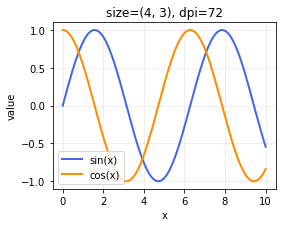

In [30]:
from IPython.display import Image, display

display(Image(filename='assets/line_medium_100dpi.png'))

## 10. JPEG image (minimal)

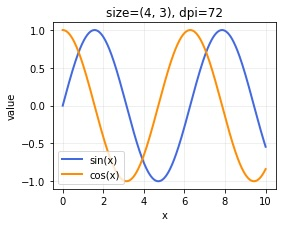

In [43]:
from IPython.display import Image, display

display(Image(filename='assets/line_small_72dpi.jpeg'))

## 11. GIF image (1×1 transparent)

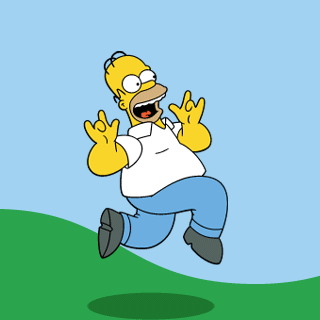

In [44]:
from IPython.display import Image, display

display(Image(filename='assets/homer.gif'))

## 12. Plotly — `application/vnd.plotly.v1+json`

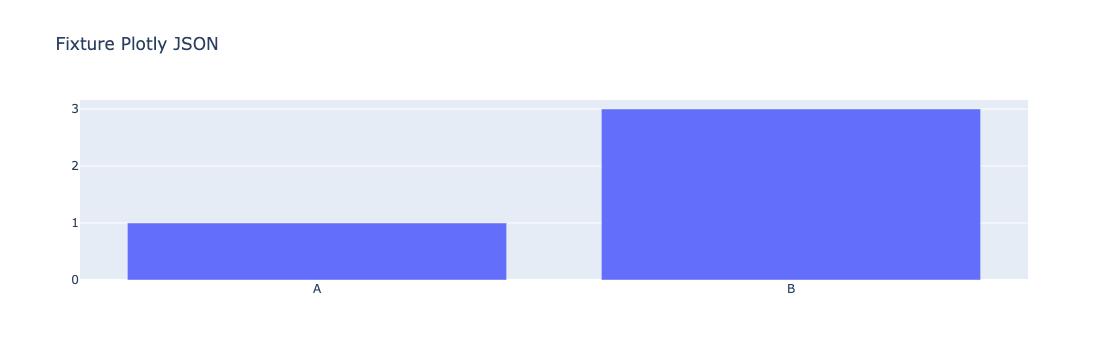

In [37]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Bar(x=['A', 'B'], y=[1, 3])])
fig.update_layout(title='Fixture Plotly JSON')
fig

## 13. Plotly — `text/vnd.plotly.v1+html`

In [39]:
from IPython.core.getipython import get_ipython

get_ipython().display_pub.publish(
    data={'text/vnd.plotly.v1+html': '<div>Plotly HTML repr</div>'},
    metadata={}
)

## 14. Fallback — unknown MIME only

Expect “Unsupported mime type: …”.

In [41]:
from IPython.core.getipython import get_ipython

get_ipython().display_pub.publish(
    data={'application/x-orion-unknown': 'mystery payload'},
    metadata={}
)

## 15. Hidden output (`metadata.orion.hidden`)

Expect placeholder “Output hidden (click to show)” when Orion hides the output.

In [27]:
from IPython.core.getipython import get_ipython

get_ipython().display_pub.publish(
    data={'text/plain': 'This output is marked hidden in Orion metadata.'},
    metadata={'orion': {'hidden': True}}
)

This output is marked hidden in Orion metadata.

## 16. Multiple outputs (stream + execute_result)

In [22]:
print('Printed before result')
'last expression'

Printed before result


'last expression'

## 17. Empty `data` object

Expect fallback with empty MIME list.

In [28]:
from IPython.core.getipython import get_ipython

get_ipython().display_pub.publish(
    data={},
    metadata={}
)

## 18. Plain text with angle brackets

Ensures `text/plain` is escaped (no invisible/broken DOM from `<...>`).

In [24]:
class PlainOnly:
    def __repr__(self):
        return '<IPython.core.display.Markdown object>'

PlainOnly()

<IPython.core.display.Markdown object>

## 11. SVG image (`image/svg+xml`)

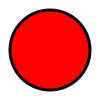

In [45]:
from IPython.display import SVG, display

svg_data = '<svg height="100" width="100"><circle cx="50" cy="50" r="40" stroke="black" stroke-width="3" fill="red" /></svg>'
display(SVG(svg_data))

In [46]:
## Long error output fixture
def long_error():
    """Generates a long, multi-line error traceback."""
    def level_5():
        raise RuntimeError("Something went wrong deep in the stack!")
    def level_4():
        level_5()
    def level_3():
        level_4()
    def level_2():
        level_3()
    def level_1():
        level_2()
    level_1()

long_error()

RuntimeError: Something went wrong deep in the stack!

```mermaid
graph LR
    A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
    B --> C{Contains Mermaid?}
    C -->|Yes| D[Render SVG Diagram]
    C -->|No| E[Render Standard HTML]
```

In [47]:
from IPython.display import display, Markdown

mermaid_code = """
```mermaid
graph LR
    A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
    B --> C{Contains Mermaid?}
    C -->|Yes| D[Render SVG Diagram]
    C -->|No| E[Render Standard HTML]
```
"""
display(Markdown(mermaid_code))


```mermaid
graph LR
    A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
    B --> C{Contains Mermaid?}
    C -->|Yes| D[Render SVG Diagram]
    C -->|No| E[Render Standard HTML]
```


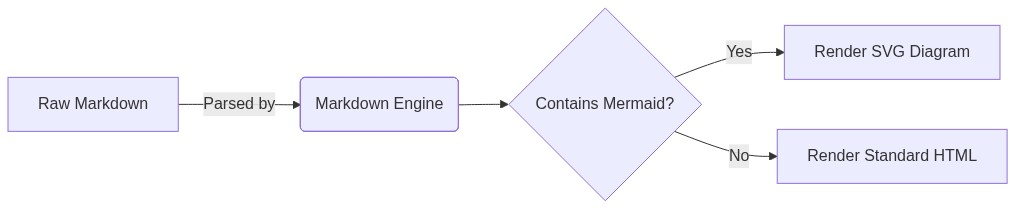

In [48]:
import base64
import requests
import json
from IPython.display import Image, display

graph = """
graph LR
    A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
    B --> C{Contains Mermaid?}
    C -->|Yes| D[Render SVG Diagram]
    C -->|No| E[Render Standard HTML]
"""

# Prepare the data required by mermaid.ink
payload = {
  "code": graph,
  "mermaid": {"theme": "default"}
}
encoded_string = base64.urlsafe_b64encode(json.dumps(payload).encode('utf-8')).decode('utf-8')
url = f"https://mermaid.ink/img/{encoded_string}"

# Fetch and display the image
response = requests.get(url)
display(Image(data=response.content, format='jpeg'))

In [49]:
from IPython.display import display, HTML

html_code = """
<div class="mermaid">
graph LR
    A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
    B --> C{Contains Mermaid?}
    C -->|Yes| D[Render SVG Diagram]
    C -->|No| E[Render Standard HTML]
</div>

<script type="module">
    import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
    mermaid.initialize({ startOnLoad: true });
</script>
"""

display(HTML(html_code))

In [50]:
import base64
from IPython.display import HTML, display

html_content = """
<!DOCTYPE html>
<html>
<head>
  <script type="module">
    import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
    mermaid.initialize({ startOnLoad: true });
  </script>
</head>
<body style="margin:0; padding:10px; font-family:sans-serif;">
  <div class="mermaid">
    graph LR
        A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
        B --> C{Contains Mermaid?}
        C -->|Yes| D[Render SVG Diagram]
        C -->|No| E[Render Standard HTML]
  </div>
</body>
</html>
"""

b64_html = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')
iframe_html = f'<iframe src="data:text/html;base64,{b64_html}" width="100%" height="300px" style="border:none;"></iframe>'
display(HTML(iframe_html))

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [51]:
from IPython.display import display, Javascript

js_code = """
// Create a unique ID for the container
const containerId = 'mermaid-' + Date.now();
// In Jupyter environments, 'element' is the jQuery object for the cell output
element.append('<div id="' + containerId + '">Loading interactive diagram...</div>');

// Dynamically import Mermaid from CDN
import('https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs').then(module => {
    const mermaid = module.default;
    mermaid.initialize({ startOnLoad: false, theme: 'default' });
    
    const graphDefinition = `
graph LR
    A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
    B --> C{Contains Mermaid?}
    C -->|Yes| D[Render SVG Diagram]
    C -->|No| E[Render Standard HTML]
    `;
    
    // Render the SVG and inject it into our container
    mermaid.render('graph-' + Date.now(), graphDefinition).then(result => {
        document.getElementById(containerId).innerHTML = result.svg;
    }).catch(err => {
        document.getElementById(containerId).innerHTML = '<span style="color:red;">Error rendering: ' + err + '</span>';
    });
});
"""

display(Javascript(js_code))

<IPython.core.display.Javascript object>

In [52]:
import uuid
from IPython.display import display, HTML, Javascript

# Generate a unique ID for the container
div_id = "mermaid_" + str(uuid.uuid4()).replace("-", "")

# Display the raw Mermaid text inside a hidden div
display(HTML(f"""
<div class="mermaid" id="{div_id}" style="display: none; padding: 20px;">
graph LR
    A[Raw Markdown] -->|Parsed by| B(Markdown Engine)
    B --> C{{Contains Mermaid?}}
    C -->|Yes| D[Render SVG Diagram]
    C -->|No| E[Render Standard HTML]
</div>
"""))

# Inject Javascript to load the CDN script the old-fashioned way and render it
js = f"""
// Define a function to render our specific diagram
function renderMyDiagram() {{
    var container = document.getElementById('{div_id}');
    if (container) {{
        container.style.display = 'block';
        mermaid.initialize({{ startOnLoad: false, theme: 'default' }});
        mermaid.init(undefined, container);
    }}
}}

// If mermaid is already loaded, render immediately
if (typeof mermaid !== 'undefined') {{
    renderMyDiagram();
}} else {{
    // Otherwise, load the script into the document head
    var script = document.createElement('script');
    script.src = 'https://cdnjs.cloudflare.com/ajax/libs/mermaid/9.4.3/mermaid.min.js';
    script.onload = function() {{
        renderMyDiagram();
    }};
    // Fallback if the script fails to load
    script.onerror = function() {{
        var container = document.getElementById('{div_id}');
        if (container) {{
            container.style.display = 'block';
            container.innerHTML = '<span style="color:red;">Failed to load Mermaid library from CDN. Check network/firewall.</span>';
        }}
    }};
    document.head.appendChild(script);
}}
"""
display(Javascript(js))

<IPython.core.display.Javascript object>